
# 00 — การสำรวจข้อมูล (Exploratory Data Analysis)

**โปรเจค:** แบบจำลอง CNN + Transfer Learning + Data Augmentation สำหรับรู้จำตัวอักษร/ตัวเลขภาษาไทย 72 คลาส

หมายเหตุเกี่ยวกับขอบเขตข้อมูล (ประวัติการแก้ไข)
---
ชุดข้อมูลชุดแรกที่ทีมได้รับมามีเพียง 31 โฟลเดอร์คลาส (จาก 72 คลาสตามโจทย์) และไม่มีไฟล์ label mapping ใด ๆ ต่อมาทีมได้รับ**ชุดข้อมูลฉบับสมบูรณ์ 72 คลาส** (โฟลเดอร์ `ThaiCharacter Dataset/round2/`) พร้อมไฟล์ `label.json` ที่ระบุว่าโฟลเดอร์ตัวเลขแต่ละอันตรงกับอักษร/สระ/วรรณยุกต์/ตัวเลขไทยตัวใด EDA ฉบับนี้จึงวิเคราะห์จากชุดข้อมูลฉบับสมบูรณ์ทั้ง 72 คลาส

- `src/data_utils.py` โหลด `label.json` เข้าเป็น `CLASS_ID_TO_THAI` (dict `{class_id: อักษรไทย}`) โดยอัตโนมัติ ทุก plot/ตารางในโปรเจคนี้จึงแสดงทั้ง class ID (ชื่อโฟลเดอร์) และอักษรไทยจริงควบคู่กัน
- `class_id` (ชื่อโฟลเดอร์ตัวเลข) ยังคงเป็น key หลักที่ใช้ขับเคลื่อน pipeline ทั้งหมด (label mapping ใช้เพื่อแสดงผลเท่านั้น) เพื่อไม่ให้การพึ่งพาไฟล์ label.json ที่มาทีหลังกระทบต่อความถูกต้องของ pipeline เดิม
</cell id="c9824ff8">


In [1]:
%matplotlib inline
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

from src.data_utils import list_images, class_counts_table, DATA_ROOT, CLASS_ID_TO_THAI, class_label_display
from src.viz_utils import plot_class_distribution, show_image_grid

pd.set_option("display.max_rows", 80)
print("Dataset root:", DATA_ROOT)
print("จำนวนคลาสที่มี label mapping (label.json):", len(CLASS_ID_TO_THAI))

Dataset root: C:\Users\Acer\Desktop\deep\ThaiCharacter Dataset\round2
จำนวนคลาสที่มี label mapping (label.json): 72


## 1. ภาพรวมของชุดข้อมูล

In [2]:

df = list_images()
n_images = len(df)
n_classes = df["class_id"].nunique()
print(f"จำนวนภาพทั้งหมด: {n_images:,} ภาพ")
print(f"จำนวนคลาสทั้งหมด: {n_classes} คลาส (folder IDs ใน round2/)")
df.head()


จำนวนภาพทั้งหมด: 62,707 ภาพ
จำนวนคลาสทั้งหมด: 72 คลาส (folder IDs ใน round2/)


,filepath,class_id,filename
0,C:\Users\Acer\Desktop\deep\ThaiCharacter Datas...,161,bc_001sg_3_118.jpg
1,C:\Users\Acer\Desktop\deep\ThaiCharacter Datas...,161,bc_001sg_3_140.jpg
2,C:\Users\Acer\Desktop\deep\ThaiCharacter Datas...,161,bc_001sg_3_142.jpg
3,C:\Users\Acer\Desktop\deep\ThaiCharacter Datas...,161,bc_001sg_3_32.jpg
4,C:\Users\Acer\Desktop\deep\ThaiCharacter Datas...,161,bc_001sg_3_42.jpg


In [3]:
classes_df = pd.DataFrame({
    "class_id": sorted(df["class_id"].unique(), key=lambda c: int(c)),
})
classes_df["thai_char"] = classes_df["class_id"].map(CLASS_ID_TO_THAI)
classes_df["n_images"] = classes_df["class_id"].map(df["class_id"].value_counts())
print("รายชื่อทั้ง 72 คลาส (class ID จากชื่อโฟลเดอร์ -> อักษรไทยจาก label.json):")
classes_df

รายชื่อทั้ง 72 คลาส (class ID จากชื่อโฟลเดอร์ -> อักษรไทยจาก label.json):


,class_id,thai_char,n_images
0,161,ก,1951
1,162,ข,1355
2,163,ฃ,1
3,164,ค,1448
4,167,ง,1078
5,168,จ,1202
6,169,ฉ,43
7,170,ช,1013
8,171,ซ,295
9,173,ญ,113



**สรุป:** ชุดข้อมูลมีทั้งหมด 62,707 ภาพ กระจายอยู่ใน 72 คลาส (folder ID) ครบตามที่ระบุในโจทย์ต้นฉบับ แต่ละคลาสสอดคล้องกับพยัญชนะ/สระ/วรรณยุกต์/ตัวเลขไทยตามไฟล์ `label.json` (แสดงในตารางหัวข้อถัดไป)
</cell id="5e7c8cff">


## 2. จำนวนข้อมูลต่อคลาส (Class Distribution) — ตารางและกราฟ

In [4]:
counts = class_counts_table(df)
counts["thai_char"] = counts["class_id"].map(CLASS_ID_TO_THAI)
counts = counts[["class_id", "thai_char", "count"]]
counts.columns = ["class_id", "อักษรไทย", "จำนวนภาพ"]
counts

,class_id,อักษรไทย,จำนวนภาพ
0,210,า,5025
1,185,น,4863
2,195,ร,4663
3,209,ั,4120
4,193,ม,3306
5,205,อ,3272
6,229,ๅ,2310
7,194,ย,2197
8,197,ล,2187
9,180,ด,2025


In [5]:

print("คลาสที่มีข้อมูลมากที่สุด 5 อันดับแรก:")
display(counts.head(5))
print("\nคลาสที่มีข้อมูลน้อยที่สุด 5 อันดับแรก:")
display(counts.tail(5))

imbalance_ratio = counts["จำนวนภาพ"].max() / counts["จำนวนภาพ"].min()
print(f"\nอัตราส่วนความไม่สมดุล (max/min) = {imbalance_ratio:,.0f} เท่า")
print(f"ค่ามัธยฐาน (median) จำนวนภาพต่อคลาส = {counts['จำนวนภาพ'].median():.0f}")


คลาสที่มีข้อมูลมากที่สุด 5 อันดับแรก:


,class_id,อักษรไทย,จำนวนภาพ
0,210,า,5025
1,185,น,4863
2,195,ร,4663
3,209,ั,4120
4,193,ม,3306



คลาสที่มีข้อมูลน้อยที่สุด 5 อันดับแรก:


,class_id,อักษรไทย,จำนวนภาพ
67,206,ฮ,10
68,247,๗,4
69,204,ฬ,3
70,163,ฃ,1
71,177,ฑ,1



อัตราส่วนความไม่สมดุล (max/min) = 5,025 เท่า
ค่ามัธยฐาน (median) จำนวนภาพต่อคลาส = 221


Saved figure -> C:\Users\Acer\Desktop\deep\outputs\figures\00_class_distribution.png


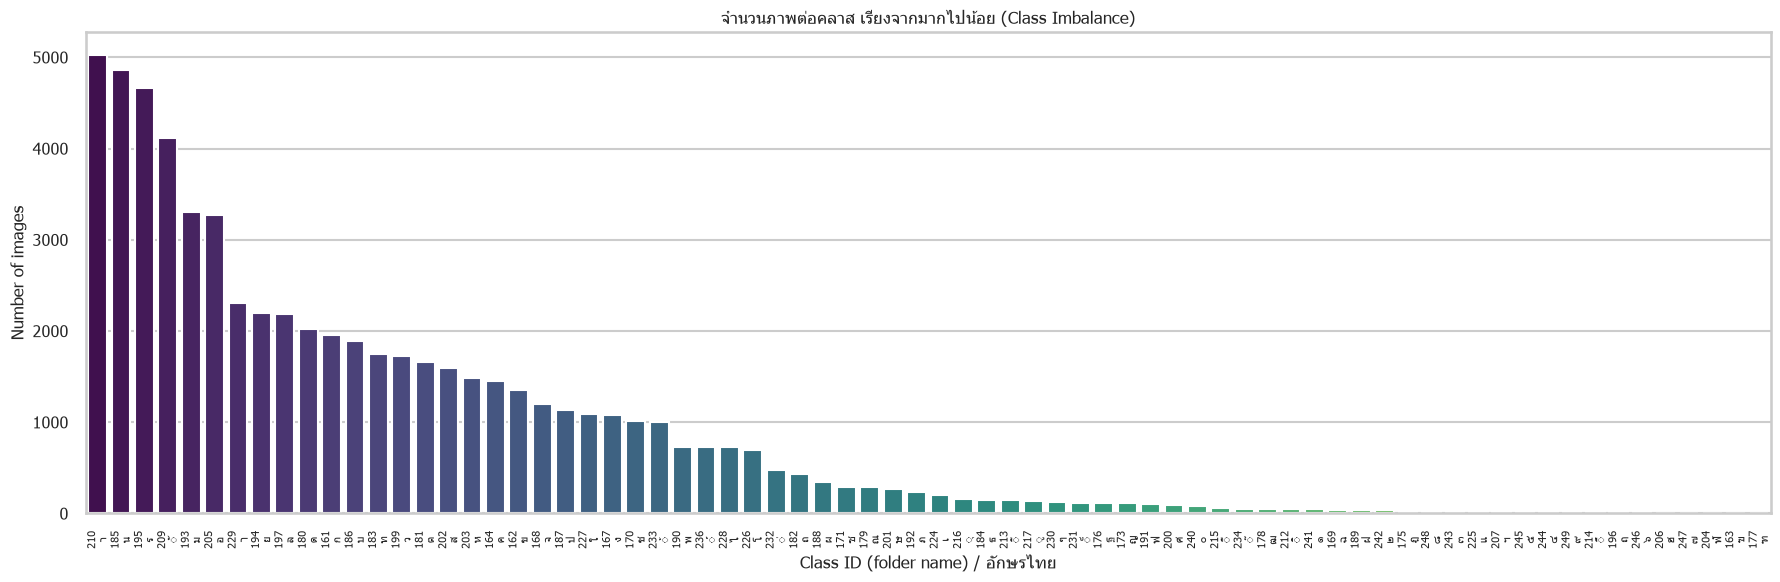

In [6]:
plot_counts = class_counts_table(df)  # unrenamed columns for the plot helper
fig = plot_class_distribution(plot_counts, class_id_to_thai=CLASS_ID_TO_THAI)


**ข้อสังเกต:** ชุดข้อมูลนี้มีความไม่สมดุลระหว่างคลาสสูงมาก — คลาสที่มีข้อมูลมากที่สุด (`210` / า, 5,025 ภาพ) มีภาพมากกว่าคลาสที่น้อยที่สุดกว่า 5,000 เท่า และมีคลาส 2 คลาส (`163`/ฃ, `177`/ฑ) ที่มีภาพเพียง**คลาสละ 1 ภาพเท่านั้น** ซึ่งเป็นกรณีร้ายแรงที่ต้องจัดการเป็นพิเศษตอนแบ่ง Train/Validation (ดู notebook `01_preprocessing_augmentation.ipynb`)
</cell id="f3586d1e">


## 3. ตัวอย่างภาพจริงจากชุดข้อมูล

Saved figure -> C:\Users\Acer\Desktop\deep\outputs\figures\00_sample_images_grid.png


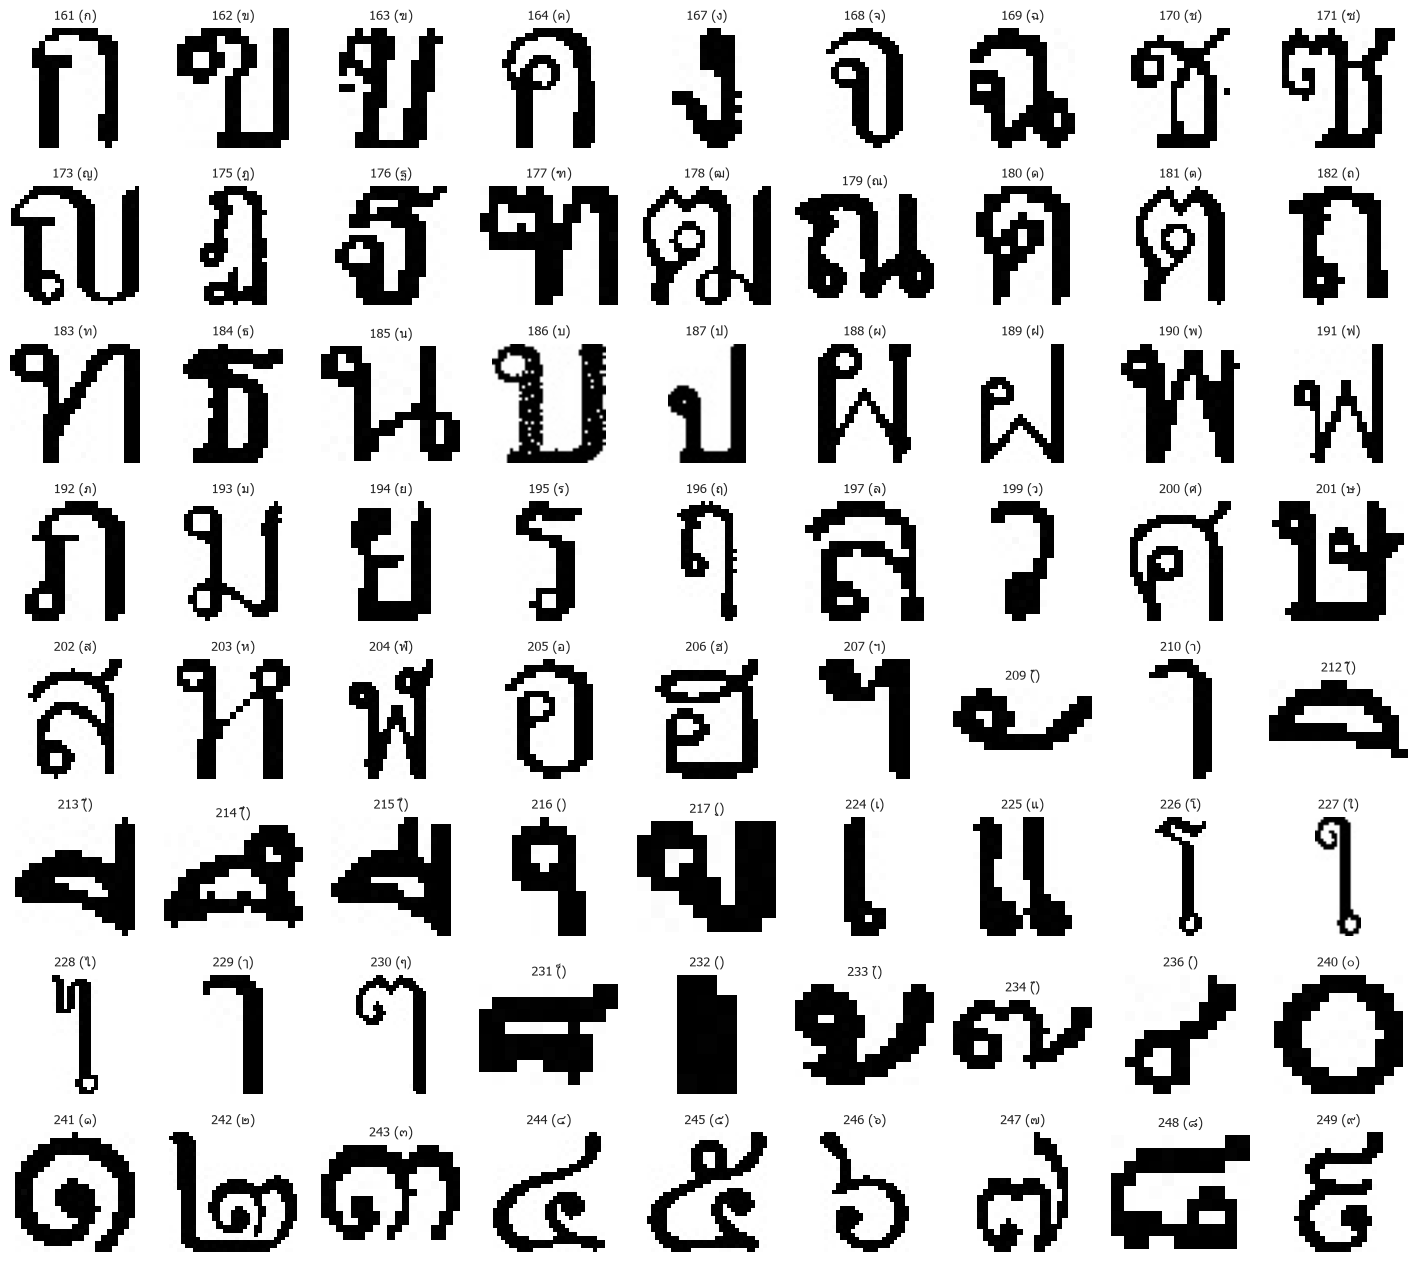

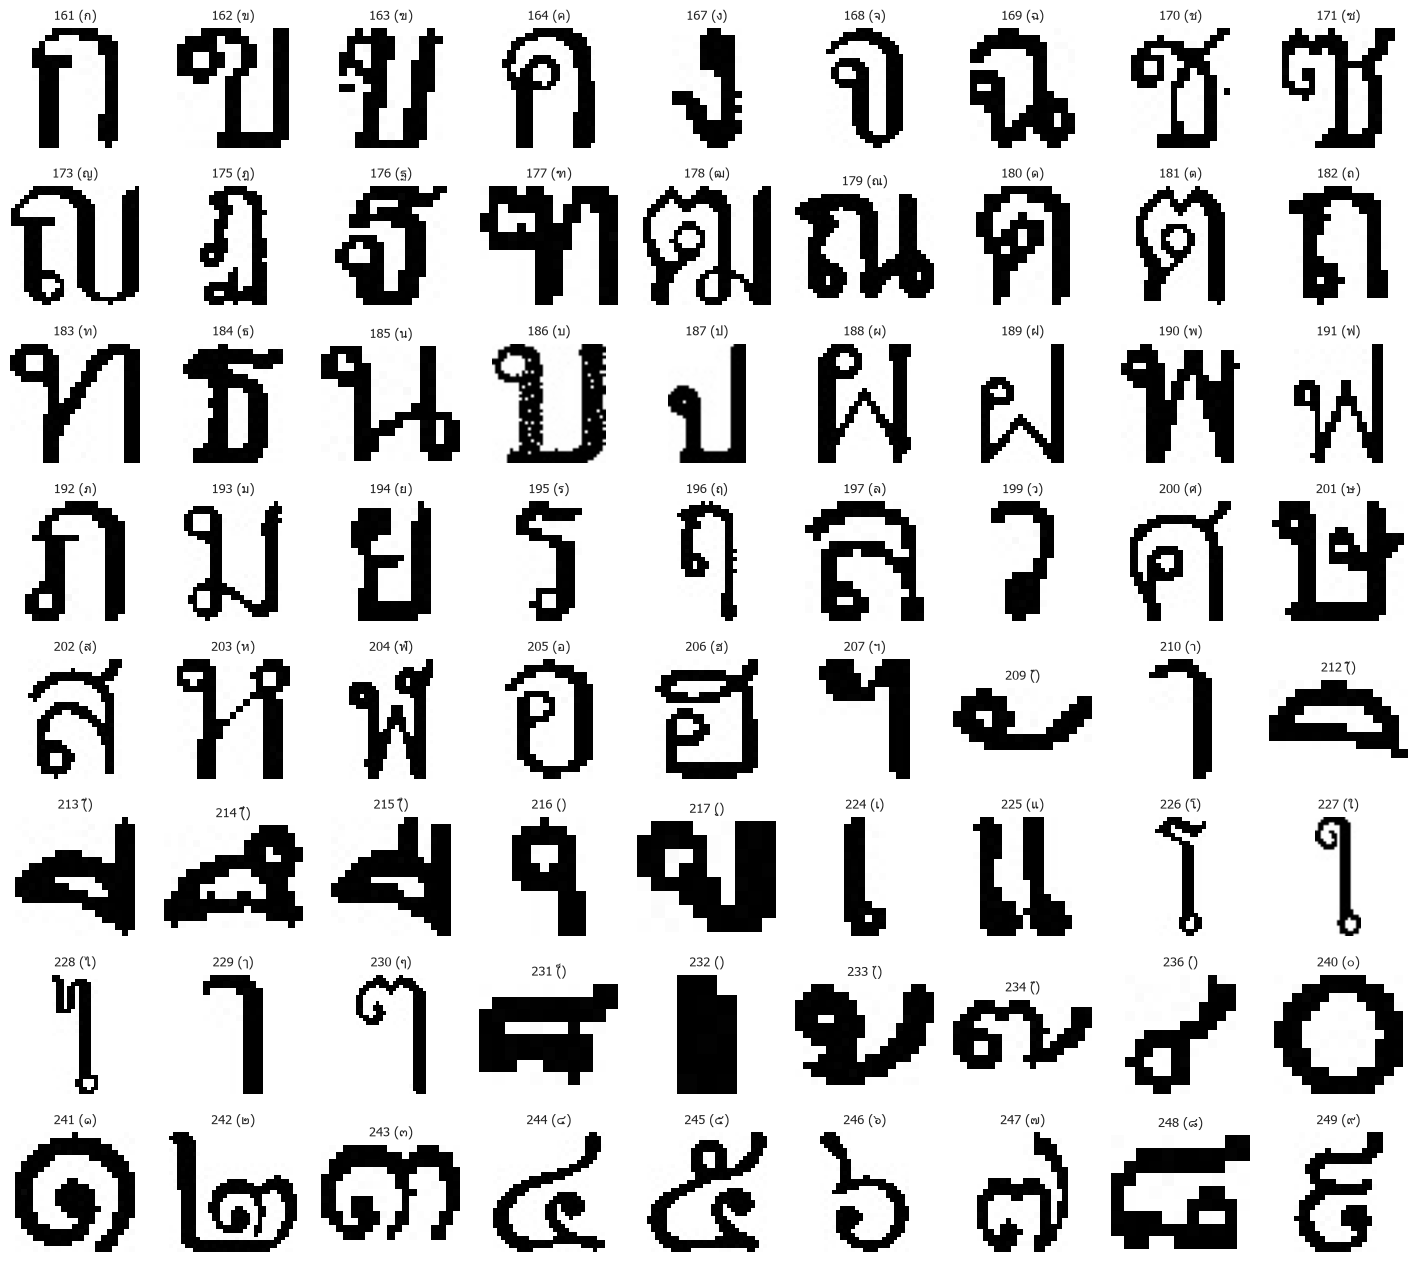

In [7]:
rng = np.random.RandomState(7)
all_classes_sorted = sorted(df["class_id"].unique(), key=lambda c: int(c))
imgs, titles = [], []
for cid in all_classes_sorted:
    sub = df[df["class_id"] == cid]
    pick = sub.sample(1, random_state=7)
    for _, row in pick.iterrows():
        with Image.open(row["filepath"]) as im:
            imgs.append(np.array(im.convert("RGB")))
            titles.append(class_label_display(cid))

show_image_grid(imgs, titles, ncols=9, name="00_sample_images_grid.png", figsize_scale=1.6)


สังเกตว่าภาพทุกภาพเป็นภาพขาวดำ (grayscale) ตัวอักษร/ตัวเลขสีเข้มบนพื้นหลังสีอ่อน ตัดขอบมาแล้วเฉพาะบริเวณตัวอักษร ขนาดภาพเล็กมากและมีสัดส่วนกว้าง/ยาวไม่เท่ากันในแต่ละภาพ


## 4. คุณสมบัติของภาพ: ขนาดและโหมดสี

In [8]:

rng = np.random.RandomState(0)
sample_df = df.sample(3000, random_state=0)
widths, heights, modes = [], [], []
for fp in sample_df["filepath"]:
    with Image.open(fp) as im:
        w, h = im.size
        widths.append(w); heights.append(h); modes.append(im.mode)

widths = np.array(widths); heights = np.array(heights)
from collections import Counter
mode_counts = Counter(modes)

print(f"สุ่มตรวจสอบ {len(sample_df)} ภาพจากทั้งหมด {len(df)} ภาพ")
print(f"ความกว้าง (width):  min={widths.min()}, median={np.median(widths):.0f}, mean={widths.mean():.1f}, max={widths.max()}")
print(f"ความสูง (height):   min={heights.min()}, median={np.median(heights):.0f}, mean={heights.mean():.1f}, max={heights.max()}")
print(f"โหมดสี (color mode) ที่พบ: {dict(mode_counts)}  (L = grayscale 8-bit)")


สุ่มตรวจสอบ 3000 ภาพจากทั้งหมด 62707 ภาพ
ความกว้าง (width):  min=3, median=16, mean=16.4, max=40
ความสูง (height):   min=5, median=19, mean=21.0, max=69
โหมดสี (color mode) ที่พบ: {'L': 3000}  (L = grayscale 8-bit)


Saved figure -> C:\Users\Acer\Desktop\deep\outputs\figures\00_image_size_distribution.png


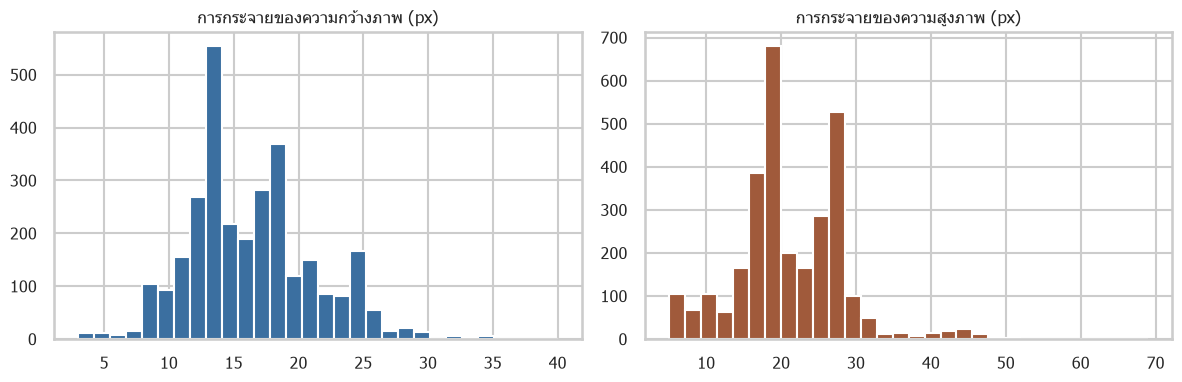

In [9]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths, bins=30, color="#3b6fa0")
axes[0].set_title("การกระจายของความกว้างภาพ (px)")
axes[1].hist(heights, bins=30, color="#a05a3b")
axes[1].set_title("การกระจายของความสูงภาพ (px)")
fig.tight_layout()
from src.viz_utils import savefig
savefig(fig, "00_image_size_distribution.png")
plt.show()



**ข้อสังเกต:** ภาพทั้งหมดเป็น **grayscale (โหมด `L`)** และมีขนาดเล็กมาก (กว้าง/สูงเพียงหลักสิบพิกเซล มัธยฐานประมาณ 16×19 พิกเซล) ซึ่งเล็กกว่า input size ทั่วไปของโมเดล pretrained บน ImageNet (เช่น 96×96 หรือ 224×224) มาก การขยายภาพขึ้น (upscale) จะทำให้เกิด blur/interpolation artifact ซึ่งเป็นความท้าทายที่ต้องพิจารณาในขั้นตอนเตรียมข้อมูล
</cell id="036f64d8">


## 5. วิเคราะห์ความท้าทายของชุดข้อมูลนี้ (Challenges Analysis)


### 5.1 ความไม่สมดุลของจำนวนข้อมูลต่อคลาส (Class Imbalance) — รุนแรงมาก
ดังที่แสดงในหัวข้อ 2 คลาสที่มีข้อมูลมากที่สุด (`210`/า, 5,025 ภาพ) มีจำนวนมากกว่าคลาสที่มีข้อมูลน้อยที่สุด (`163`/ฃ, `177`/ฑ, 1 ภาพ) กว่า 5,000 เท่า และมีถึง 2 คลาสที่มีข้อมูลเพียง 1 ภาพ ซึ่งไม่เพียงพอต่อการเรียนรู้ pattern ใด ๆ อย่างมีนัยสำคัญ และเป็นไปไม่ได้เลยที่จะแบ่งข้อมูลของคลาสเหล่านี้ให้อยู่ทั้งใน Train และ Validation พร้อมกัน — เราจัดการเรื่องนี้ด้วยกฎการแบ่งข้อมูลแบบพิเศษใน notebook `01`

### 5.2 ความหลากหลายของลายมือ/แหล่งที่มาของตัวอย่าง
</cell id="21953459">


In [10]:

import re
pattern = re.compile(r"^([a-z]{2}_\d{3}[a-z]{2})_")
df["writer_code"] = df["filename"].str.extract(pattern)
n_unmatched = df["writer_code"].isna().sum()
n_unique_writers = df["writer_code"].nunique()
print(f"จำนวนรหัสผู้เขียน/รอบเก็บข้อมูลที่แยกได้จากชื่อไฟล์ (เช่น 'bc_001sg'): {n_unique_writers} รหัส")
print(f"ชื่อไฟล์ที่แยกรหัสไม่ได้: {n_unmatched} ไฟล์ (จาก {len(df)})")

writers_per_class = df.groupby("class_id")["writer_code"].nunique().sort_values()
print("\nคลาสที่มีความหลากหลายของแหล่งที่มาน้อยที่สุด (writer code นับได้น้อย):")
display(writers_per_class.head(5))
print("คลาสที่มีความหลากหลายมากที่สุด:")
display(writers_per_class.tail(5))


จำนวนรหัสผู้เขียน/รอบเก็บข้อมูลที่แยกได้จากชื่อไฟล์ (เช่น 'bc_001sg'): 102 รหัส
ชื่อไฟล์ที่แยกรหัสไม่ได้: 6 ไฟล์ (จาก 62707)

คลาสที่มีความหลากหลายของแหล่งที่มาน้อยที่สุด (writer code นับได้น้อย):


class_id
163    1
177    1
204    2
247    4
196    4
Name: writer_code, dtype: int64

คลาสที่มีความหลากหลายมากที่สุด:


class_id
197    100
181    101
183    102
210    102
185    102
Name: writer_code, dtype: int64


**ข้อสังเกต:** ชื่อไฟล์ในชุดข้อมูลมีรูปแบบสม่ำเสมอ (เช่น `bc_001sg_3_118.jpg`) ซึ่งสามารถแยกส่วนต้นออกมาเป็น "รหัสที่คาดว่าเป็นผู้เขียนหรือรอบการเก็บข้อมูล" ได้ครบทุกไฟล์ พบว่ามีรหัสไม่ซ้ำกันมากถึง 102 รหัส บ่งชี้ว่าข้อมูลถูกเก็บมาจากหลายคน/หลายรอบ ซึ่งควรทำให้มีความหลากหลายของลายมือสูง — **แต่ความหลากหลายนี้ไม่กระจายเท่ากันทุกคลาส**: คลาสที่มีจำนวนภาพน้อย (เช่น `163` (ฃ), `177` (ฑ)) ก็มีจำนวนรหัสผู้เขียนน้อยตามไปด้วย (1 รหัสเท่านั้น) หมายความว่าคลาสเหล่านี้ไม่ได้แค่ "มีข้อมูลน้อย" แต่ยัง "ขาดความหลากหลายของสไตล์การเขียน" ไปพร้อมกัน ซึ่งซ้ำเติมปัญหาการเรียนรู้ของโมเดลในคลาสส่วนน้อยให้หนักขึ้นไปอีก

### 5.3 ความคล้ายคลึงกันระหว่างคลาส (Visual Similarity)
จากรายชื่อ 72 คลาสในหัวข้อ 1 (ได้จาก `label.json`) มีอักษร/สระไทยหลายคู่ที่รูปทรงคล้ายกันมากจนแม้มนุษย์เองบางครั้งยังสับสน โดยเฉพาะเมื่อภาพต้นฉบับมีขนาดเล็กมาก (ดูหัวข้อ 4):

- **ศ (200) / ษ (201) / ส (202)** — พยัญชนะ "ส" สามตัวที่ออกเสียงคล้ายกันและรูปทรงก็ใกล้เคียงกันมาก ต่างกันที่รายละเอียดหัว/หางเพียงเล็กน้อย
- **ป (187) / ฝ (189)** และ **ถ (182) / ภ (192)** — คู่พยัญชนะที่มีเส้นโครงสร้างหลักเหมือนกัน ต่างกันที่ขีด/จุดเสริมเล็ก ๆ
- **ุ (216) / ู (217)** และ **ึ (214) / ื (215)** — สระบนกับสระล่างที่ต่างกันแค่จำนวน/ทิศทางของหาง ซึ่งในภาพขนาด ~17×21 พิกเซลอาจเหลือเพียงไม่กี่พิกเซลที่ใช้แยกความต่างได้
- **่ (232) / ้ (233) / ๊ (234)** — วรรณยุกต์ 3 ตัวที่เป็นเพียงขีด/จุดเล็ก ๆ เหนือตัวอักษร ต่างกันที่รูปทรงของขีดเท่านั้น

เราจะ**วัดความคล้ายคลึงนี้เชิงปริมาณจริง**ด้วย Confusion Matrix ใน notebook `04_evaluation_prediction.ipynb` ซึ่งจะชี้ชัดว่าคู่คลาสใดที่โมเดลสับสนกันบ่อยที่สุดในทางปฏิบัติ

### 5.4 ขนาดภาพต้นฉบับเล็กมากและมีสัญญาณรบกวนจากการขยายภาพ
ตามที่แสดงในหัวข้อ 4 ภาพต้นฉบับมีขนาดเพียงหลักสิบพิกเซล (มัธยฐาน ~17×21 พิกเซล) การขยายภาพให้เข้ากับ input size ของ backbone pretrained (96×96) จะทำให้เกิดการ interpolate ซึ่งทำให้เส้นขอบตัวอักษรเบลอ/เป็นบั้ง ส่งผลให้รายละเอียดเล็ก ๆ ที่ใช้แยกแยะอักษรที่คล้ายกัน (เช่น ตำแหน่งจุด/หาง ตามหัวข้อ 5.3) อาจสูญหายไปบางส่วน

### 5.5 ภาพเป็น grayscale แต่โมเดล pretrained ต้องการ 3 ช่องสัญญาณ (RGB)
โมเดล backbone ที่ pretrained บน ImageNet (MobileNetV2, EfficientNetB0 ฯลฯ) รับ input เป็นภาพ 3 channel (RGB) แต่ภาพในชุดข้อมูลนี้เป็น grayscale ล้วน (โหมด `L`) จึงต้องแปลงเป็น 3 channel ก่อน (โดย stack ช่องเดียวกันซ้ำ 3 ครั้ง) ซึ่งจัดการในขั้นตอนเตรียมข้อมูล (notebook `01`)

### 5.6 ประวัติไฟล์ label mapping
ชุดข้อมูลฉบับแรกที่ทีมได้รับไม่มีไฟล์ label mapping และมีเพียง 31 คลาส ทำให้ช่วงแรกของโปรเจคต้องอ้างอิงด้วย class ID ล้วน ๆ ภายหลังทีมได้รับชุดข้อมูลฉบับสมบูรณ์ 72 คลาสพร้อม `label.json` ซึ่งเป็นข้อมูลที่ใช้ในการวิเคราะห์ทั้งหมดตั้งแต่หัวข้อ 1 ของ notebook นี้เป็นต้นไป
</cell id="7765bedb">



## 6. สรุป EDA

| ประเด็น | ค่าที่พบจริง |
|---|---|
| จำนวนภาพทั้งหมด | 62,707 |
| จำนวนคลาส | 72 (ครบตามโจทย์ต้นฉบับ) |
| จำนวนภาพต่อคลาส (min / median / max) | 1 / 221 / 5,025 |
| จำนวนคลาสที่มีภาพเพียง 1 ภาพ | 2 คลาส (163/ฃ, 177/ฑ) |
| ขนาดภาพ (median) | ~16×19 พิกเซล, grayscale |
| จำนวนรหัสผู้เขียน/รอบเก็บข้อมูลที่พบ | 102 รหัส (กระจายไม่เท่ากันในแต่ละคลาส) |

ผลการสำรวจนี้กำหนดทิศทางของขั้นตอนถัดไปโดยตรง: ต้องมีกลยุทธ์แบ่งข้อมูลที่รองรับคลาสขนาดเล็กมาก (notebook 01), ต้องใช้ Data Augmentation ที่ไม่ทำลายความหมายของตัวอักษร (ห้าม flip), ต้องมีเทคนิคจัดการ class imbalance ตอนเทรน (Focal Loss, notebook 02–03), และต้องใช้ Transfer Learning เพื่อชดเชยข้อมูลที่มีจำกัดต่อคลาส (notebook 02)
</cell id="41140c4e">
